In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
def thomas_algorithm(a,b,d,B,ti,tf,h,alpha,beta):
    N = len(b)
    y = np.zeros(N)
    a[0] = a[0]/d[0]
    B[0] = B[0]/d[0]

    for i in range(1, N - 1):
        a[i]  = a[i] / (d[i] - b[i]*a[i - 1])
        B[i] = (B[i] - b[i]*B[i - 1]) / (d[i] - b[i]*a[i - 1])

    B[N - 1] = (B[N - 1] - b[N - 1]*B[N - 2]) / (d[N - 1] - b[N - 1]*a[N - 2])
    y[N - 1] = B[N - 1]

    for i in range(N - 2, -1, -1):
        y[i] = B[i] - a[i]*y[i + 1]

    return y


In [5]:
def f(x,y,dy):
    return (1/8) * (32 + 2 * (x ** 3) - y * dy)

def f_y(x,y,dy):
    return (1/8) * (- dy)

def f_dy(x,y,dy):
    return (1/8) * (- y)

def real_f(x):
    return x ** 2 + (16 / x)

def diferencas_finitas(ti,tf,h,alpha,beta,f,f_y,f_dy,max_iter):
    #Definindo o número de intervalos, pontos e pontos internos
    N_intervalos = int(np.round((tf - ti)/h))
    N_pontos = N_intervalos + 1
    N_interno = N_pontos - 2
    y = np.zeros(N_pontos)
    x = np.linspace(ti,tf,N_pontos)

    #Chute inicial dos valores de y
    y[0] = alpha
    y[-1] = beta
    for i in range(1,N_pontos - 1):
        y[i] = alpha + i*h*((beta - alpha) / (tf - ti))

    #Definindo os vetores da matriz tridiagonal da jacobiana

    a = np.zeros(N_interno) #Diagonal principal
    b = np.zeros(N_interno) #Diagonal superior
    c = np.zeros(N_interno) #Diagonal inferior
    d = np.zeros(N_pontos) #F(Y)

    #Tolerância para o problema
    tol = 1e-8
    k = 1
    while(k <= max_iter):
        #Definindo os valores do primeiro elemento da diagonal principal, diagonal superior(caso o número de pontos internos seja maior que 1) e o primeiro valor de -F(Y)
        t = (y[2] - alpha)/(2*h)
        a[0] = 2 + h**2*f_y(x[1],y[1],t)
        if(N_interno > 1):
            b[0] = -1 + (h/2)*f_dy(x[1],y[1],t)
        d[0] = -(2*y[1] - y[2] - alpha + h**2*f(x[1],y[1],t))

        #Determinando os valores das diagonais
        for i in range(1,N_interno - 1):
            idx = i + 1 #Indíce que irá percorrer o vetor do tempo e o vetor y
            t = (y[idx + 1] - y[idx - 1]) / (2*h)
            a[i] = 2 + h**2*f_y(x[idx],y[idx],t)
            b[i] = -1 + (h/2)*f_dy(x[idx],y[idx],t)
            c[i] = -1 - (h/2)*f_dy(x[idx],y[idx],t)
            d[i] = - (2*y[idx] - y[idx + 1] - y[idx - 1] + h**2*f(x[idx],y[idx],t))


        if(N_interno > 1):
            idx = N_pontos - 2   # último ponto interno
            t = (beta - y[idx - 1]) / (2*h)
            a[N_interno - 1] = 2 + h**2 * f_y(x[idx], y[idx], t)
            c[N_interno - 1] = -1 - (h/2) * f_dy(x[idx], y[idx], t)
            d[N_interno - 1] = -(2*y[idx] - y[idx - 1] - beta
                                + h**2 * f(x[idx], y[idx], t))



        #Algorítmo de Thomas e Newton
        v = np.zeros(N_interno)
        if(N_interno == 1):
            v[0] = d[0] / a[0]
        else:
            v = thomas_algorithm(b,c,a,d,ti,tf,h,alpha,beta)
        y[1:-1] += v

        if(np.max(abs(v)) < tol):
            return x,y,k;
        k += 1

    print("O procedimento não foi bem sucedido. O número máximo de iterações foi excedido")

    return x,y,k


In [6]:
t,w,k = diferencas_finitas(1,3,0.1,17,43/3,f,f_y,f_dy,100)

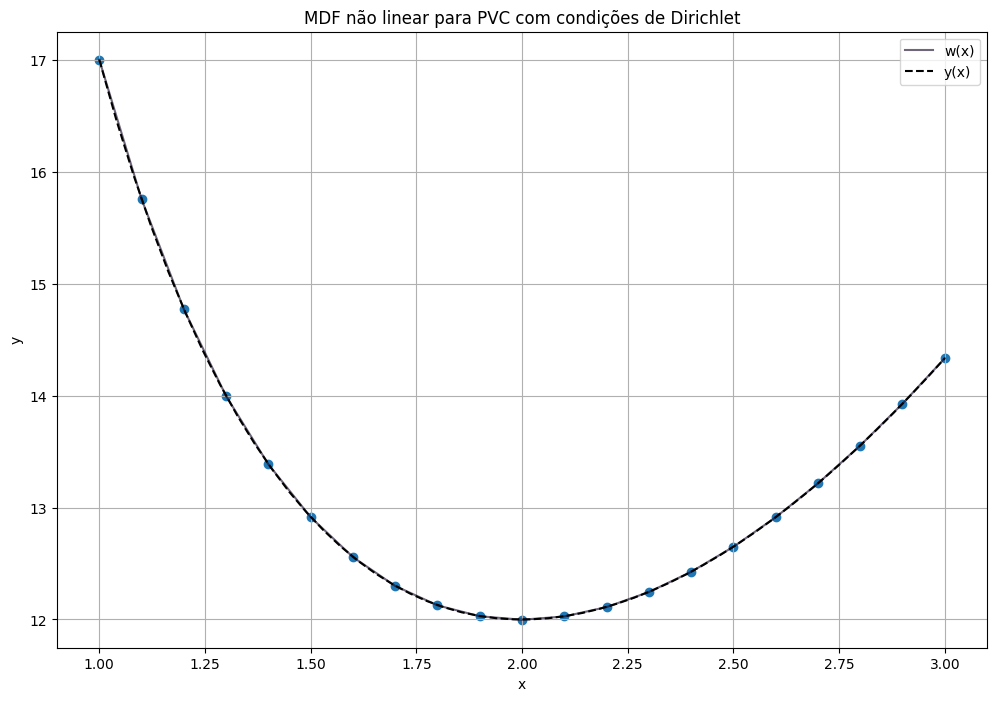

In [7]:
t_aprox, w = t,w
t_real = np.linspace(1,3)
plt.figure(figsize = (12,8))
plt.plot(t_aprox, w, color = "#1029", label = "w(x)")
plt.title("MDF não linear para PVC com condições de Dirichlet")
plt.plot(t_real,real_f(t_real), label = "y(x)", color = "black", linestyle = "--")
plt.scatter(t_aprox,w)
plt.legend()
plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.show()
